# 🧩 Resolución de Ejercicio – KMeans Unidimensional sobre Metalicidad Gaia DR3

### 🎯 Objetivo:
Aplicar **KMeans-Clustering unidimensional** sobre datos de **metalicidad estelar [Fe/H]**  
provenientes del subcatálogo **`gaiadr3.gold_sample_spss`** y analizar la calidad del agrupamiento.

---

## 🧭 Instrucciones:

1. Realice una **query SQL** a `gaiadr3.gold_sample_spss` para seleccionar únicamente estrellas con metalicidad válida

## 🧭 Query sugerida

```sql
SELECT source_id, feh
FROM gaiadr3.gold_sample_spss
WHERE feh IS NOT NULL
```

Guarde los resultados como `metallicity_data.csv`.


In [33]:
!pip install astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 999.4/999.4 kB 60.2 MB/s eta 0:00:00


In [ ]:
from astroquery.gaia import Gaia
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

query ='''
SELECT
source_id, feh
FROM gaiadr3.gold_sample_spss
WHERE feh IS NOT NULL

'''
job = Gaia.launch_job_async(query)
df = job.get_results().to_pandas()
len(df)

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]


50

## 1) Construya un histograma para las metalicidades de las estrellas. A partir de este último, cuantas agrupaciones (clusters) puede observar? (e.g., se observan dos, tres, cinco distribuciones?). Guarde los valores medios de metalicidad que usted estima para cada distribución observada. Recuerde incluir título y labels en su histograma. ##

## 2) Usando el número de clusters (n clusters) del apartado anterior, realize un Kmeans-clustering usando la siguiente instrucción:



```
feh = df['feh'].values
```

```
km=KMeans(n clusters=valor encontrado).fit(feh.reshape(-1,1))
```

```
km.predict(feh.reshape(-1,1))
```





## 3) A continuación, imprima a pantalla los valores de los centroides encontrados por KMeans:
km.cluster centers

## 4) ¿Coinciden estos últimos con los valores que usted estimó anteriormente?


## 5) Con la siguiente instrucción: `'km.inertia'`
### Puede conocer el valor de la función F (vista en clases) para su clustering (donde F es el valor m ́ınimo encontrado de la suma de las distancias al cuadrado de cada punto de cada cluster a su centroide).

## 6) Repita el proceso anterior desde el inicio, pero esta vez considere un número de clusters igual a n+1 del considerado anteriormente. ¿Cómo cambia el valor para F?"

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

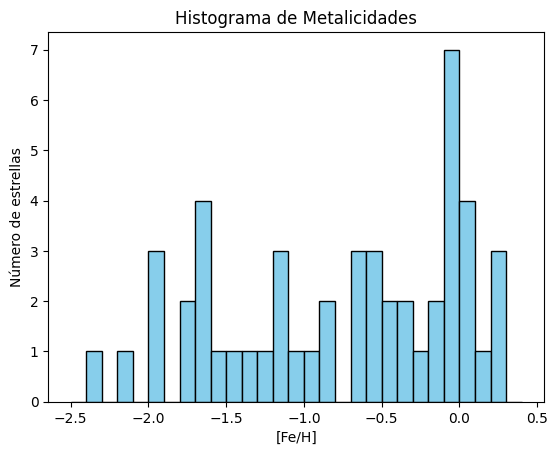

In [ ]:
plt.hist(df['feh'], bins=np.arange(-2.5,0.5,0.1), color='skyblue', edgecolor='black')
plt.xlabel('[Fe/H]')
plt.ylabel('Número de estrellas')
plt.title('Histograma de Metalicidades')
plt.show()

In [ ]:
n_clusters = 2
feh = df['feh'].values
km = KMeans(n_clusters=n_clusters, random_state=42).fit(feh.reshape(-1,1))
print("Centroides encontrados:", km.cluster_centers_.flatten())
centroids2 = km.cluster_centers_.flatten()  #Valor de los centroides
print("Inercia (F):", km.inertia_)
labels_2 = km.labels_


Centroides encontrados: [-0.22956187 -1.5718949 ]
Inercia (F): 5.925130367279053


In [ ]:
n_clusters_plus = n_clusters + 1
km_plus = KMeans(n_clusters=n_clusters_plus, random_state=42).fit(feh.reshape(-1,1))
print("Centroides con n+1 clusters:", km_plus.cluster_centers_.flatten())
centroids3 = km_plus.cluster_centers_.flatten() #Valor de los centroides
print("Inercia (F) con n+1 clusters:", km_plus.inertia_)
labels_3 = km_plus.labels_


Centroides con n+1 clusters: [ 0.00457346 -1.6351917  -0.6409732 ]
Inercia (F) con n+1 clusters: 3.041594982147217


In [ ]:
labels_2

array([1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 0], dtype=int32)

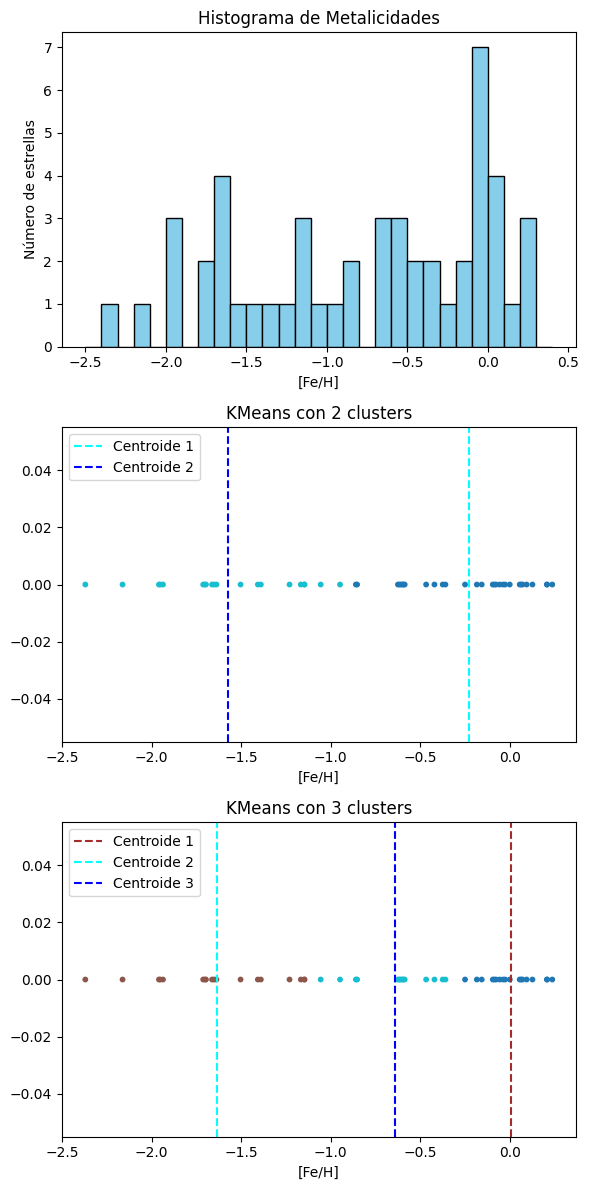

In [ ]:
plt.figure(figsize=(6, 12))  # ancho x alto

# Panel 1: Histograma
plt.subplot(3, 1, 1)
plt.hist(feh, bins=np.arange(-2.5, 0.5, 0.1), color='skyblue', edgecolor='black')
plt.xlabel('[Fe/H]')
plt.ylabel('Número de estrellas')
plt.title('Histograma de Metalicidades')

# Panel 2: KMeans con 2 clusters
plt.subplot(3, 1, 2)

plt.scatter(feh, np.zeros_like(feh), c=labels_2, cmap='tab10', s=10)
plt.title('KMeans con 2 clusters')
plt.xlabel('[Fe/H]')
plt.axvline(centroids2[0], color='cyan', linestyle='--', label='Centroide 1')
plt.axvline(centroids2[1], color='b', linestyle='--', label='Centroide 2')
plt.legend()

# Panel 3: KMeans con 3 clusters
plt.subplot(3, 1, 3)

plt.scatter(feh, np.zeros_like(feh), c=labels_3, cmap='tab10', s=10)
plt.title('KMeans con 3 clusters')
plt.xlabel('[Fe/H]')
plt.axvline(centroids3[0], color='brown', linestyle='--', label='Centroide 1')
plt.axvline(centroids3[1], color='cyan', linestyle='--', label='Centroide 2')
plt.axvline(centroids3[2], color='b', linestyle='--', label='Centroide 3')
plt.legend()

# Ajustar espacios
plt.tight_layout()
plt.show()


## 🧩 Ejercicio 2 – KMeans con datos de Gapminder

Aplicaremos KMeans sobre un conjunto de datos que contiene indicadores socioeconómicos de países.

🎯 Objetivo:
Aplicar el algoritmo **KMeans** para agrupar países en función de sus indicadores de **PIB per cápita** y **esperanza de vida**,  
y analizar las características generales de los grupos formados.

---

## 🧭 Instrucciones:

1. Cargue el dataset de Gapminder para el año más reciente.
2. Seleccione los indicadores `gdpPercap` y `lifeExp`.
3. Aplique **KMeans con 3 clusters** sobre los datos escalados.
4. Visualice los resultados, identificando cada país con su nombre.

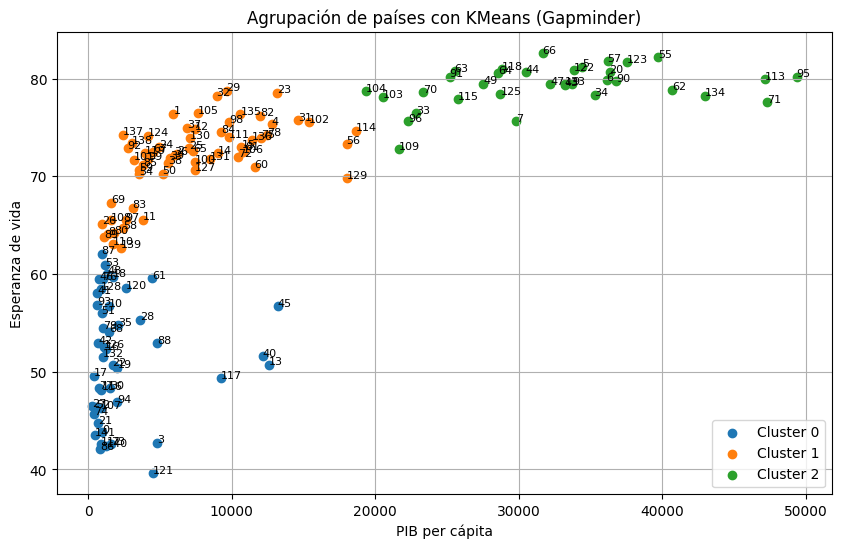

Nombre de paises separados por clasificación: 
 country_id                  country  cluster
          0              Afghanistan        0
          3                   Angola        0
         10                    Benin        0
         13                 Botswana        0
         16             Burkina Faso        0
         17                  Burundi        0
         18                 Cambodia        0
         19                 Cameroon        0
         21 Central African Republic        0
         22                     Chad        0
         27          Congo Dem. Rep.        0
         28               Congo Rep.        0
         30            Cote d'Ivoire        0
         35                 Djibouti        0
         40        Equatorial Guinea        0
         41                  Eritrea        0
         42                 Ethiopia        0
         45                    Gabon        0
         46                   Gambia        0
         48                    Gh

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Cargar datos desde GitHub
url = "https://raw.githubusercontent.com/resbaz/r-novice-gapminder-files/master/data/gapminder-FiveYearData.csv"
df = pd.read_csv(url)

# Filtrar por el año más reciente
latest = df[df['year'] == df['year'].max()][['country', 'gdpPercap', 'lifeExp']]
latest = latest.reset_index(drop=True)
latest['country_id'] = latest.index  # asignar ID numérico

data = latest[['gdpPercap', 'lifeExp']]

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)
latest['cluster'] = labels

# Gráfico usando IDs numéricos
plt.figure(figsize=(10, 6))
for label in latest['cluster'].unique():
    subset = latest[latest['cluster'] == label]
    plt.scatter(subset['gdpPercap'], subset['lifeExp'], label=f'Cluster {label}')
    for i, row in subset.iterrows():
        plt.text(row['gdpPercap'], row['lifeExp'], str(row['country_id']), fontsize=8)

plt.xlabel('PIB per cápita')
plt.ylabel('Esperanza de vida')
plt.title('Agrupación de países con KMeans (Gapminder)')
plt.legend()
plt.grid(True)
plt.show()

# Mostrar tabla con ID y nombre de país
pd.set_option('display.max_rows', None)
#print(latest[['country_id', 'country', 'cluster']].sort_values('country_id').to_string(index=False))
for label in latest['cluster'].unique():
  print(f"Nombre de paises separados por clasificación: ")
  subset = latest[latest['cluster'] == label]
  print(subset[['country_id', 'country', 'cluster']].sort_values('country_id').to_string(index=False))




🔍 Análisis:

- Los clusters muestran agrupaciones claras entre países de **alto ingreso/alta esperanza de vida**,  
  **bajo ingreso/baja esperanza de vida**, y **casos intermedios o en transición**.
- El algoritmo KMeans divide según **distancia euclidiana** en el espacio de los indicadores,  
  por lo que la escala debe ser estandarizada, como se hizo con `StandardScaler`.
- Visualizar los nombres permite identificar **qué países representan cada grupo**, lo que es clave para interpretar políticas o desarrollo regional.


# 🧩 Ejercicio 3 – Clustering Jerárquico con Datos de Vinos (UCI)

## 🎯 Objetivo:
Aplicar **clustering jerárquico** sobre un conjunto de datos reales sobre vinos.  
Visualizar las relaciones entre muestras con un **dendrograma**, y asignar identificadores a las muestras para facilitar su análisis.

---

## 🧭 Instrucciones:

1. Cargar el dataset de vinos desde `sklearn.datasets.load_wine()`.
2. Aplicar el método de linkage jerárquico (`ward`).
3. Visualizar el dendrograma jerárquico.
4. Etiquetar las muestras con un número (índice) y mostrar la tabla con su categoría real y cluster.


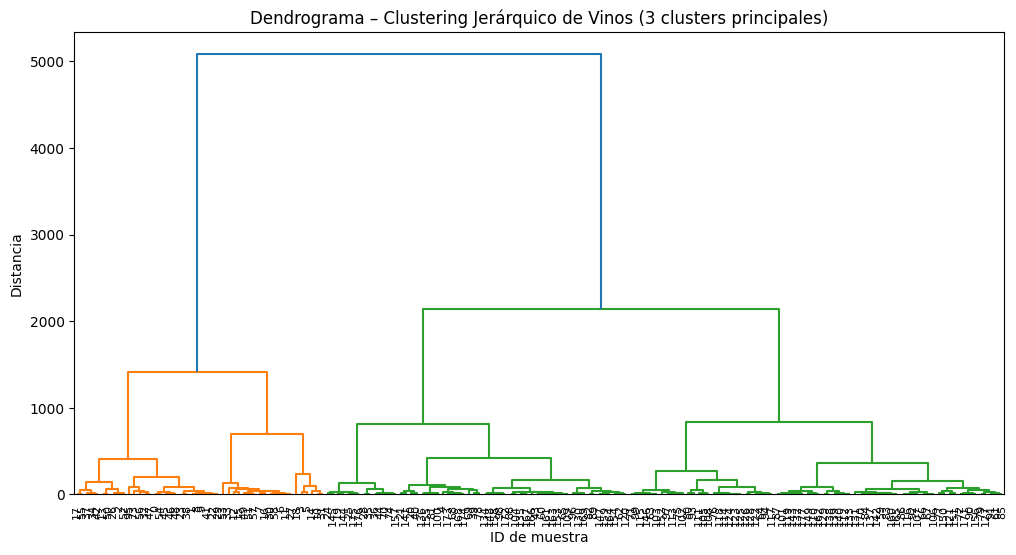

Cluster 1 contiene muestras: [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 22, 23, 26, 27, 29, 30, 31, 32, 33, 34, 37, 38, 41, 42, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 73, 95]
Cluster 2 contiene muestras: [4, 19, 20, 21, 24, 25, 28, 35, 36, 39, 40, 43, 44, 60, 62, 65, 68, 69, 70, 74, 78, 81, 82, 88, 89, 96, 98, 100, 104, 109, 120, 130, 134, 135, 136, 141, 144, 145, 147, 148, 153, 154, 155, 157, 158, 159, 161, 163, 164, 166, 167, 168, 169, 172, 173, 174, 175, 176]
Cluster 3 contiene muestras: [59, 61, 63, 64, 66, 67, 71, 72, 75, 76, 77, 79, 80, 83, 84, 85, 86, 87, 90, 91, 92, 93, 94, 97, 99, 101, 102, 103, 105, 106, 107, 108, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 121, 122, 123, 124, 125, 126, 127, 128, 129, 131, 132, 133, 137, 138, 139, 140, 142, 143, 146, 149, 150, 151, 152, 156, 160, 162, 165, 170, 171, 177]


In [28]:
from sklearn.datasets import load_wine
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt
import pandas as pd

# Cargar datos
wine = load_wine()
X = wine.data
target = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

# Crear DataFrame con ID
df = pd.DataFrame(X, columns=feature_names)
df['sample_id'] = df.index
df['target'] = target

# Construir linkage
linked = linkage(X, method='ward')

# Cortar dendrograma en 3 clusters principales
clusters = fcluster(linked, t=3, criterion='maxclust')
df['cluster'] = clusters

# Graficar dendrograma con etiquetas numéricas
plt.figure(figsize=(12, 6))
dendrogram(linked,
           labels=df['sample_id'].values,
           leaf_rotation=90,
           leaf_font_size=8,
           color_threshold=None)
plt.title('Dendrograma – Clustering Jerárquico de Vinos (3 clusters principales)')
plt.xlabel('ID de muestra')
plt.ylabel('Distancia')
plt.show()

# Imprimir las muestras agrupadas por cluster
for i in sorted(df['cluster'].unique()):
    ids = df[df['cluster'] == i]['sample_id'].tolist()
    print(f"Cluster {i} contiene muestras: {ids}")

## 🔍 Análisis:

- El dendrograma fue cortado para mostrar **3 clusters principales**.
- Se imprimen los **IDs de las muestras** contenidas en cada uno de esos clusters.
- Esta agrupación ayuda a interpretar el resultado jerárquico como si fueran clases discretas.

Este tipo de corte permite **resumir la estructura del dendrograma** y conectar con métodos de clustering clásico.


# 🧩 Ejercicio 4 – Detección de Agrupaciones de Terremotos con DBSCAN (USGS)

## 🎯 Objetivo:
Aplicar **DBSCAN** para identificar agrupaciones naturales de terremotos recientes a partir de sus **coordenadas geográficas**.

---

## 🧭 Instrucciones:

1. Descargar los datos de terremotos de los últimos 7 días desde la web del **USGS**.
2. Extraer las columnas `latitude` y `longitude`.
3. Aplicar DBSCAN con una distancia angular (`eps`) apropiada y visualizar los clusters.
4. Contar cuántas agrupaciones distintas fueron detectadas y cuántos eventos fueron clasificados como ruido.


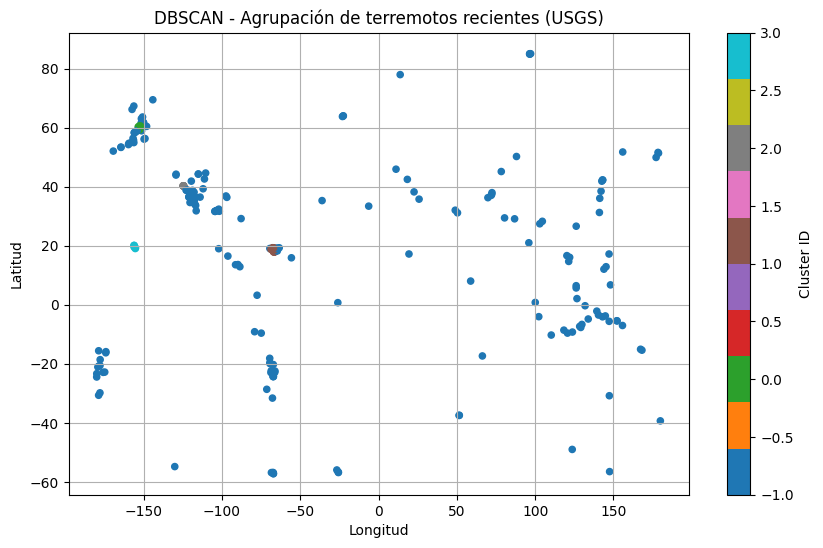

Se detectaron 4 agrupaciones.
190 terremotos fueron clasificados como ruido.


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# Descargar datos desde USGS (últimos 7 días, magnitud >= 2.5)
url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/2.5_week.csv"
df = pd.read_csv(url)

# Extraer coordenadas
coords = df[['latitude', 'longitude']].dropna().values

# Aplicar DBSCAN
eps = 1.0  # Aproximadamente ~100 km si no se transforma
min_samples = 5
db = DBSCAN(eps=eps, min_samples=min_samples).fit(coords)
labels = db.labels_

# Añadir al DataFrame
df = df.iloc[coords[:, 0].argsort()]
df['cluster'] = labels

# Visualización
plt.figure(figsize=(10, 6))
scatter = plt.scatter(coords[:, 1], coords[:, 0], c=labels, cmap='tab10', s=20)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('DBSCAN - Agrupación de terremotos recientes (USGS)')
plt.grid(True)
plt.colorbar(scatter, label='Cluster ID')
plt.show()

# Resumen
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"Se detectaron {n_clusters} agrupaciones.")
print(f"{n_noise} terremotos fueron clasificados como ruido.")

## 🔍 Análisis:

- DBSCAN identifica agrupaciones densas de terremotos y descarta eventos aislados como **ruido**.
- La elección del parámetro `eps` influye directamente en qué tan compacto debe ser un cluster para ser detectado.
- Este tipo de análisis es útil para detectar **zonas sísmicas activas**, enjambres o réplicas.

Puede aplicarse también a coordenadas transformadas en coordenadas UTM o en distancias geodésicas si se requiere mayor precisión.


🧩 Ejercicio 5 – DBSCAN aplicado al Diagrama HR con Datos Reales de Gaia

## 🎯 Objetivo:
Obtener una muestra limpia de estrellas desde **Gaia DR3**, construir el **diagrama HR corregido por distancia**  
(magnitud absoluta G vs BP-RP), y aplicar **DBSCAN** para detectar agrupaciones estelares.

---**descargados manualmente desde Gaia DR3** mediante una consulta SQL.

---

## 🧭 Instrucciones:

1. Ejecuta la siguiente consulta SQL en el [Gaia Archive](https://gea.esac.esa.int/archive/) o usando TOPCAT:

```sql
SELECT
    source_id,
    bp_rp,
    phot_g_mean_mag,
    parallax,
    phot_bp_mean_flux_over_error,
    phot_rp_mean_flux_over_error,
    astrometric_excess_noise,
    ruwe
FROM gaiadr3.gaia_source
WHERE
    parallax > 1
    AND bp_rp BETWEEN -1 AND 5
    AND phot_g_mean_mag BETWEEN 5 AND 20
    AND phot_bp_mean_flux_over_error > 10
    AND phot_rp_mean_flux_over_error > 10
    AND ruwe < 1.4
    AND astrometric_excess_noise < 1
ORDER BY random_index
LIMIT 5000

In [47]:
from astroquery.gaia import Gaia
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

query ='''
SELECT
source_id, ra, dec, parallax, bp_rp, pmra, pmdec, phot_g_mean_mag
FROM gaiadr3.gaia_source
WHERE ra BETWEEN 322 AND 323 AND dec BETWEEN 11.5 AND 12.5
AND parallax BETWEEN 0.1 AND 0.2
AND phot_g_mean_mag < 24
'''

job = Gaia.launch_job_async(query)
df = job.get_results().to_pandas()

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]


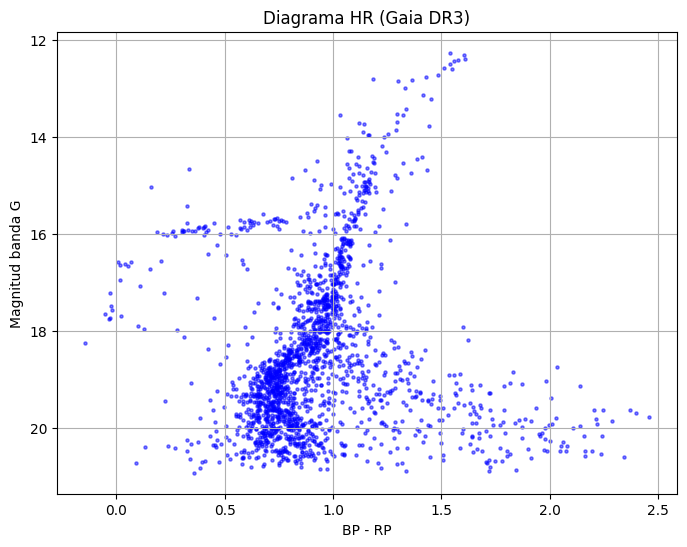

In [48]:
plt.figure(figsize=(8,6))
plt.scatter(df['bp_rp'], df['phot_g_mean_mag'], s=5, alpha=0.5, color='blue')
plt.gca().invert_yaxis()
plt.xlabel('BP - RP')
plt.ylabel('Magnitud banda G')
plt.title('Diagrama HR (Gaia DR3)')
plt.grid(True)
plt.show()

In [49]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

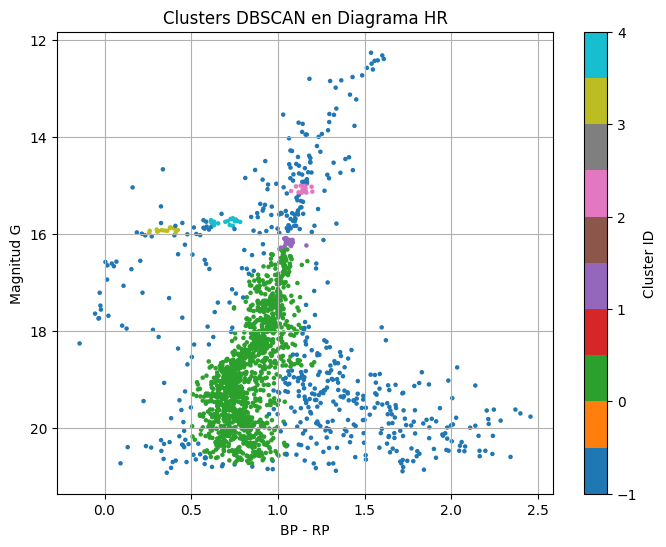

Se detectaron 5 agrupaciones estelares.
530 estrellas fueron clasificadas como ruido.


In [75]:
X = df[['bp_rp', 'phot_g_mean_mag']].copy()
X = X.dropna()
scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)
#DBSCAN
db = DBSCAN(eps=0.1, min_samples=15).fit(X)
labels = db.labels_
#Asignar etiquetas al DataFrame filtrado
df_clust = df.loc[X.index].copy()
df_clust['cluster'] = labels
#Visualización
plt.figure(figsize=(8,6))
scatter = plt.scatter(df_clust['bp_rp'], df_clust['phot_g_mean_mag'], c=labels, cmap='tab10', s=5)
plt.gca().invert_yaxis()
plt.xlabel('BP - RP')
plt.ylabel('Magnitud G')
plt.title('Clusters DBSCAN en Diagrama HR')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True)
plt.show()
#Reporte
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"Se detectaron {n_clusters} agrupaciones estelares.")
print(f"{n_noise} estrellas fueron clasificadas como ruido.")

## 🔍 Análisis Final:

    DBSCAN permite detectar estructuras densas dentro del diagrama HR,
    como la secuencia principal, la rama de gigantes, o grupos de enanas blancas.

    Puedes ajustar eps y min_samples para detectar estructuras más pequeñas o filamentos extendidos.

Este tipo de análisis es útil para estudios de poblaciones estelares, cúmulos o estructuras evolutivas en HR.